# 03 — Estrategia cuantitativa y Backtesting

En este notebook se desarrolla y evalúa la primera estrategia cuantitativa
del proyecto utilizando datos históricos de Bitcoin (BTC-USD).

La estrategia estará basada en el cruce de dos medias móviles simples:

- **SMA 20:** media móvil de corto plazo.
- **SMA 50:** media móvil de mediano plazo.

La hipótesis inicial es que una SMA de corto plazo situada por encima de una
SMA de mayor período puede representar una tendencia alcista.

La estrategia utilizará dos estados:

- **Long (1):** SMA 20 > SMA 50.
- **Fuera del mercado (0):** SMA 20 <= SMA 50.

El objetivo será evaluar si esta estrategia puede ofrecer un comportamiento
competitivo frente a una estrategia pasiva de **Buy & Hold**, considerando
tanto rentabilidad como riesgo.

Durante el notebook se realizarán las siguientes etapas:

1. Carga y preparación de datos.
2. Construcción de medias móviles.
3. Generación de señales.
4. Construcción de posiciones.
5. Backtesting de la estrategia.
6. Construcción del benchmark Buy & Hold.
7. Comparación de rentabilidad acumulada.
8. Evaluación de riesgo.
9. Incorporación de costos de transacción.
10. Análisis de resultados y conclusiones.

## 1. Importación de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Carga de datos

Los datos históricos utilizados por la estrategia fueron obtenidos y
almacenados durante la etapa de adquisición de datos.

Este notebook utiliza directamente el archivo CSV generado previamente,
permitiendo separar la adquisición de datos del desarrollo y evaluación
de la estrategia.

In [5]:
btc = pd.read_csv(
    "../data/raw/btc_usd.csv",
    index_col="Date",
    parse_dates=True
)

btc.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2018-01-01,13657.200195,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


In [6]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3182 entries, 2018-01-01 to 2026-09-17
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  3182 non-null   float64
 1   Close      3182 non-null   float64
 2   High       3182 non-null   float64
 3   Low        3182 non-null   float64
 4   Open       3182 non-null   float64
 5   Volume     3182 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 174.0 KB


In [7]:
btc.isna().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

## 3. Feature Engineering

Para identificar posibles tendencias se construirán dos medias móviles
simples (Simple Moving Average):

- SMA 20
- SMA 50

La SMA 20 representa una tendencia de menor plazo y responde más rápidamente
a los cambios recientes del precio.

La SMA 50 representa una tendencia más suavizada y de mayor plazo.

La relación entre ambas medias será utilizada posteriormente para generar
las señales de la estrategia.

In [9]:
btc["SMA_20"] = btc["Close"].rolling(window=20).mean()
btc["SMA_50"] = btc["Close"].rolling(window=50).mean()

btc[["Close", "SMA_20", "SMA_50"]].head(55)

,Close,SMA_20,SMA_50
Date,,,
2018-01-01,13657.200195,NaN,NaN
2018-01-02,14982.099609,NaN,NaN
2018-01-03,15201.000000,NaN,NaN
2018-01-04,15599.200195,NaN,NaN
2018-01-05,17429.500000,NaN,NaN
2018-01-06,17527.000000,NaN,NaN
2018-01-07,16477.599609,NaN,NaN
2018-01-08,15170.099609,NaN,NaN
2018-01-09,14595.400391,NaN,NaN


### Visualización de medias móviles

Antes de utilizar las medias móviles para generar señales, se visualiza su
comportamiento respecto del precio de cierre de Bitcoin.

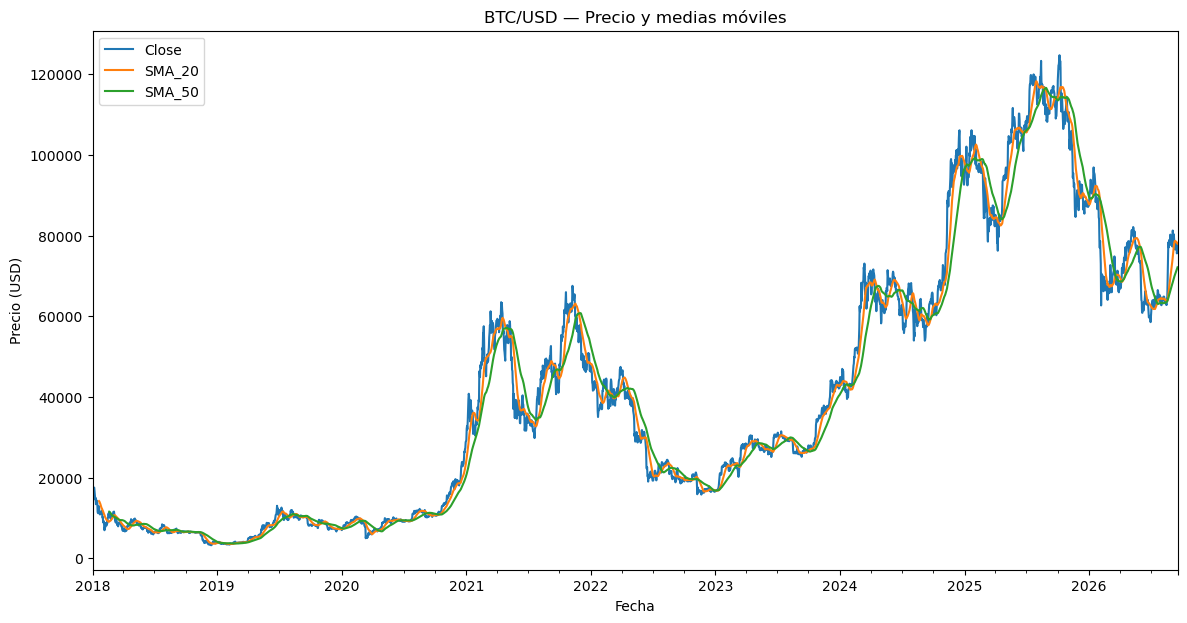

In [11]:
btc[["Close", "SMA_20", "SMA_50"]].plot(
    figsize=(14, 7),
    title="BTC/USD — Precio y medias móviles"
)

plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.show()

### Período de inicialización

Las medias móviles necesitan una cantidad mínima de observaciones antes de
poder calcularse.

En particular, la SMA 50 requiere 50 observaciones. Por este motivo, las
primeras filas no contienen información suficiente para generar una señal
válida.

Estas observaciones serán eliminadas antes de realizar el backtesting.

In [13]:
btc = btc.dropna(subset=["SMA_20", "SMA_50"]).copy()

btc[["Close", "SMA_20", "SMA_50"]].head()

,Close,SMA_20,SMA_50
Date,,,
2018-02-19,11225.299805,9103.446533,11550.002637
2018-02-20,11403.700195,9162.576563,11504.932637
2018-02-21,10690.400391,9238.569580,11419.098652
2018-02-22,10005.000000,9297.282080,11315.178652
2018-02-23,10301.099609,9353.591553,11209.216641


In [14]:
btc[["Close", "SMA_20", "SMA_50"]].isna().sum()

Close     0
SMA_20    0
SMA_50    0
dtype: int64

## 4. Generación de señales

La estrategia utilizará la relación entre las dos medias móviles para
identificar posibles períodos de tendencia alcista.

La regla será:

- **Signal = 1:** SMA 20 > SMA 50
- **Signal = 0:** SMA 20 <= SMA 50

Una señal igual a 1 indica intención de mantener una posición Long en Bitcoin.

Una señal igual a 0 indica permanecer fuera del mercado.

En esta primera versión no se utilizarán posiciones Short.

In [16]:
btc["signal"] = np.where(
    btc["SMA_20"] > btc["SMA_50"],
    1,
    0
)

btc[["Close", "SMA_20", "SMA_50", "signal"]].head()

,Close,SMA_20,SMA_50,signal
Date,,,,
2018-02-19,11225.299805,9103.446533,11550.002637,0
2018-02-20,11403.700195,9162.576563,11504.932637,0
2018-02-21,10690.400391,9238.569580,11419.098652,0
2018-02-22,10005.000000,9297.282080,11315.178652,0
2018-02-23,10301.099609,9353.591553,11209.216641,0


In [17]:
btc["signal"].value_counts()

signal
1    1640
0    1493
Name: count, dtype: int64

## 5. Construcción de posiciones

La señal generada utilizando el precio de cierre de un día solamente puede
ser utilizada después de que dicho precio sea conocido.

Por este motivo, la posición utilizada para calcular el retorno de la
estrategia será desplazada un período.

Esto evita utilizar información futura durante el backtesting
(**Look-Ahead Bias**).

In [19]:
btc["position"] = btc["signal"].shift(1)

btc[["Close", "SMA_20", "SMA_50", "signal", "position"]].head()

,Close,SMA_20,SMA_50,signal,position
Date,,,,,
2018-02-19,11225.299805,9103.446533,11550.002637,0,NaN
2018-02-20,11403.700195,9162.576563,11504.932637,0,0.0
2018-02-21,10690.400391,9238.569580,11419.098652,0,0.0
2018-02-22,10005.000000,9297.282080,11315.178652,0,0.0
2018-02-23,10301.099609,9353.591553,11209.216641,0,0.0


<div style="font-family: system-ui, -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; max-width: 400px; margin: 20px auto; padding: 15px; background-color: #f8f9fa; border-radius: 12px; border: 1px solid #e9ecef;">
  <h2 style="color: #212529; font-size: 0.95rem;">Supongamos:</h2>
  <!-- Paso 1 -->
  <div style="background: white; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #007bff; box-shadow: 0 2px 4px rgba(0,0,0,0.04); display: flex; align-items: center; justify-content: space-between;">
    <div>
      <span style="font-size: 0.75rem; text-transform: uppercase; font-weight: bold; color: #6c757d; display: block; margin-bottom: 2px;">Fase 1</span>
      <strong style="color: #212529; font-size: 0.95rem;">Día 1: Cierre</strong>
    </div>
    <span style="font-size: 1.2rem;">📊</span>
  </div>

  <!-- Flecha 1 -->
  <div style="text-align: center; margin: 8px 0; color: #007bff; font-size: 1.2rem; font-weight: bold;">↓</div>

  <!-- Paso 2 -->
  <div style="background: white; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #17a2b8; box-shadow: 0 2px 4px rgba(0,0,0,0.04); display: flex; align-items: center; justify-content: space-between;">
    <div>
      <span style="font-size: 0.75rem; text-transform: uppercase; font-weight: bold; color: #6c757d; display: block; margin-bottom: 2px;">Procesamiento</span>
      <strong style="color: #212529; font-size: 0.95rem;">Calculamos SMA</strong>
    </div>
    <span style="font-size: 1.2rem;">⚙️</span>
  </div>

  <!-- Flecha 2 -->
  <div style="text-align: center; margin: 8px 0; color: #17a2b8; font-size: 1.2rem; font-weight: bold;">↓</div>

  <!-- Paso 3 -->
  <div style="background: white; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #28a745; box-shadow: 0 2px 4px rgba(0,0,0,0.04); display: flex; align-items: center; justify-content: space-between;">
    <div>
      <span style="font-size: 0.75rem; text-transform: uppercase; font-weight: bold; color: #6c757d; display: block; margin-bottom: 2px;">Resultado</span>
      <strong style="color: #212529; font-size: 0.95rem;">Obtenemos señal</strong>
    </div>
    <span style="font-size: 1.2rem;">🎯</span>
  </div>

  <!-- Flecha 3 -->
  <div style="text-align: center; margin: 8px 0; color: #28a745; font-size: 1.2rem; font-weight: bold;">↓</div>

  <!-- Paso 4 -->
  <div style="background: white; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #dc3545; box-shadow: 0 2px 4px rgba(0,0,0,0.04); display: flex; align-items: center; justify-content: space-between;">
    <div>
      <span style="font-size: 0.75rem; text-transform: uppercase; font-weight: bold; color: #6c757d; display: block; margin-bottom: 2px;">Fase 2</span>
      <strong style="color: #212529; font-size: 0.95rem;">Día 2: Utilizamos esa señal</strong>
    </div>
    <span style="font-size: 1.2rem;">🚀</span>
  </div>

</div>

<div style="font-family: system-ui, -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; max-width: 400px; margin: 20px auto; padding: 15px; background-color: #f8f9fa; border-radius: 12px; border: 1px solid #e9ecef;">
  <h2 style="color: #212529; font-size: 0.95rem;">No queremos:</h2>
  <!-- Paso 1 -->
  <div style="background: white; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #007bff; box-shadow: 0 2px 4px rgba(0,0,0,0.04); display: flex; align-items: center; justify-content: space-between;">
    <div>
      <span style="font-size: 0.75rem; text-transform: uppercase; font-weight: bold; color: #6c757d; display: block; margin-bottom: 2px;">Fase 1</span>
      <strong style="color: #212529; font-size: 0.95rem;">Precio de hoy</strong>
    </div>
    <span style="font-size: 1.2rem;">📊</span>
  </div>

  <!-- Flecha 1 -->
  <div style="text-align: center; margin: 8px 0; color: #007bff; font-size: 1.2rem; font-weight: bold;">↓</div>

  <!-- Paso 2 -->
  <div style="background: white; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #17a2b8; box-shadow: 0 2px 4px rgba(0,0,0,0.04); display: flex; align-items: center; justify-content: space-between;">
    <div>
      <span style="font-size: 0.75rem; text-transform: uppercase; font-weight: bold; color: #6c757d; display: block; margin-bottom: 2px;">Procesamiento</span>
      <strong style="color: #212529; font-size: 0.95rem;">Señal de hoy</strong>
    </div>
    <span style="font-size: 1.2rem;">⚙️</span>
  </div>

  <!-- Flecha 2 -->
  <div style="text-align: center; margin: 8px 0; color: #17a2b8; font-size: 1.2rem; font-weight: bold;">↓</div>

  <!-- Paso 3 -->
  <div style="background: white; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #28a745; box-shadow: 0 2px 4px rgba(0,0,0,0.04); display: flex; align-items: center; justify-content: space-between;">
    <div>
      <span style="font-size: 0.75rem; text-transform: uppercase; font-weight: bold; color: #6c757d; display: block; margin-bottom: 2px;">Resultado</span>
      <strong style="color: #212529; font-size: 0.95rem;">Ganar también el retorno</strong>
    </div>
    <span style="font-size: 1.2rem;">🎯</span>
  </div>

  <!-- Flecha 3 -->
  <div style="text-align: center; margin: 8px 0; color: #28a745; font-size: 1.2rem; font-weight: bold;">↓</div>

  <!-- Paso 4 -->
  <div style="background: white; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #dc3545; box-shadow: 0 2px 4px rgba(0,0,0,0.04); display: flex; align-items: center; justify-content: space-between;">
    <div>
      <span style="font-size: 0.75rem; text-transform: uppercase; font-weight: bold; color: #6c757d; display: block; margin-bottom: 2px;">Fase 2</span>
      <strong style="color: #212529; font-size: 0.95rem;">que ya ocurrió hoy</strong>
    </div>
    <span style="font-size: 1.2rem;">❌</span>
  </div>

</div>

## 6. Retornos de la estrategia

Primero se calculan los retornos diarios de Bitcoin.

Posteriormente, el retorno de la estrategia se obtiene multiplicando el
retorno diario del activo por la posición que la estrategia mantenía
durante ese período.

In [23]:
btc["daily_return"] = btc["Close"].pct_change()

btc["strategy_return"] = (
    btc["position"] * btc["daily_return"]
)

btc[["daily_return", "position", "strategy_return"]].head()

,daily_return,position,strategy_return
Date,,,
2018-02-19,NaN,NaN,NaN
2018-02-20,0.015893,0.0,0.0
2018-02-21,-0.062550,0.0,-0.0
2018-02-22,-0.064114,0.0,-0.0
2018-02-23,0.029595,0.0,0.0


Conceptualmente:

position = 1
BTC sube 3%
→ estrategia = +3%

position = 1
BTC baja 2%
→ estrategia = -2%

position = 0
BTC sube 5%
→ estrategia = 0%

position = 0
BTC baja 4%
→ estrategia = 0%

In [25]:
btc[["daily_return", "strategy_return"]].describe()

,daily_return,strategy_return
count,3132.000000,3132.000000
mean,0.001141,0.000892
std,0.032285,0.022526
min,-0.371695,-0.143490
25%,-0.013154,-0.000333
50%,0.000618,0.000000
75%,0.014724,0.001287
max,0.187465,0.187465


In [26]:
btc[["Close", "daily_return", "signal", "position", "strategy_return"]].head(10)

,Close,daily_return,signal,position,strategy_return
Date,,,,,
2018-02-19,11225.299805,NaN,0,NaN,NaN
2018-02-20,11403.700195,0.015893,0,0.0,0.0
2018-02-21,10690.400391,-0.062550,0,0.0,-0.0
2018-02-22,10005.000000,-0.064114,0,0.0,-0.0
2018-02-23,10301.099609,0.029595,0,0.0,0.0
2018-02-24,9813.070312,-0.047376,0,0.0,-0.0
2018-02-25,9664.730469,-0.015117,0,0.0,-0.0
2018-02-26,10366.700195,0.072632,0,0.0,0.0
2018-02-27,10725.599609,0.034620,0,0.0,0.0


## 7. Benchmark — Buy & Hold

Para determinar si la estrategia aporta valor es necesario compararla con
una alternativa de referencia.

El benchmark utilizado será Buy & Hold, que consiste en mantener Bitcoin
durante todo el período analizado.

Ambas estrategias serán comparadas utilizando exactamente el mismo período
temporal.

In [28]:
btc["buy_hold_return"] = btc["daily_return"]

btc[
    [
        "Close",
        "daily_return",
        "strategy_return",
        "buy_hold_return"
    ]
].head()

,Close,daily_return,strategy_return,buy_hold_return
Date,,,,
2018-02-19,11225.299805,NaN,NaN,NaN
2018-02-20,11403.700195,0.015893,0.0,0.015893
2018-02-21,10690.400391,-0.062550,-0.0,-0.062550
2018-02-22,10005.000000,-0.064114,-0.0,-0.064114
2018-02-23,10301.099609,0.029595,0.0,0.029595


<p style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'>Puede parecer demasiado sencillo, pero conceptualmente es importante.
Buy & Hold está siempre dentro del mercado. Por lo tanto:
\[
R_{BuyHold,t}=R_{BTC,t}
\]Nuestra estrategia, en cambio:
\[
R_{Strategy,t}=Position_t\times R_{BTC,t}
\]</p>

<p>Por ejemplo:</p>

## 8. Rentabilidad acumulada

Los retornos diarios permiten analizar el comportamiento de una estrategia
período a período, pero no muestran directamente cómo habría evolucionado
una inversión a lo largo del tiempo.

Para analizar este comportamiento se calculará la rentabilidad acumulada
tanto de la estrategia basada en medias móviles como del benchmark Buy & Hold.

La acumulación de retornos se realiza mediante capitalización compuesta,
asumiendo que las ganancias y pérdidas de cada período afectan al capital
disponible para el período siguiente.

In [32]:
btc["strategy_cumulative"] = (
    1 + btc["strategy_return"].fillna(0)
).cumprod()

btc["buy_hold_cumulative"] = (
    1 + btc["buy_hold_return"].fillna(0)
).cumprod()

<p>Ejemplo:</p>

<p style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'>
No debemos hacer simplemente:
\[
10\%+5\%-10\%=5\%
\]En una inversión los retornos se componen:
\[
1\times1.10\times1.05\times0.90
\]Resultado:
\[
1.0395
\]Es decir, $1 inicial se convirtió en $1.0395, una rentabilidad acumulada de aproximadamente +3.95%.
Eso es exactamente lo que hace:
</p>

In [35]:
(1 + btc["strategy_return"]).cumprod()

Date
2018-02-19         NaN
2018-02-20    1.000000
2018-02-21    1.000000
2018-02-22    1.000000
2018-02-23    1.000000
                ...   
2026-09-13    7.445306
2026-09-14    7.573715
2026-09-15    7.326545
2026-09-16    7.378657
2026-09-17    7.428839
Name: strategy_return, Length: 3133, dtype: float64

<p>El 1 + convierte, por ejemplo:</p>

<p>y cumprod() va multiplicándolos cronológicamente.</p>

In [38]:
btc[
    [
        "strategy_cumulative",
        "buy_hold_cumulative"
    ]
].tail()

,strategy_cumulative,buy_hold_cumulative
Date,,
2026-09-13,7.445306,6.845087
2026-09-14,7.573715,6.963144
2026-09-15,7.326545,6.735901
2026-09-16,7.378657,6.783812
2026-09-17,7.428839,6.829948


<p style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'>
Recordá que ambas curvas parten de 1 unidad de capital. Por lo tanto, el valor 7.428839 significa que 1 unidad habría terminado convertida en aproximadamente 7.43 unidades bajo nuestras hipótesis actuales.
Podemos convertirlo a retorno acumulado:
\[
Return = CapitalFinal - 1
\]Entonces:
\[
7.428839 - 1 = 6.428839 \approx 642.88\%
\]Mientras que Buy & Hold:
\[
6.829948 - 1 = 5.829948 \approx 582.99\%
\]Por ahora tenemos aproximadamente:
	Capital final	Retorno acumulado
SMA 20/50	7.43×	+642.88%
Buy & Hold	6.83×	+582.99%
</p>
<p style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'>
Esto es especialmente interesante porque antes observamos que la estrategia tenía menor retorno diario promedio (0.0892% vs 0.1141%) y, sin embargo, termina con un crecimiento acumulado mayor.</p>

                                                                                                                 No es una contradicción. Los retornos son compuestos, y además importa mucho cuándo ocurren las pérdidas. Evitar algunas caídas grandes puede tener un efecto considerable sobre el capital compuesto.

                                                                                                                

<p>
Por ejemplo, perder 50% requiere después ganar 100% solamente para volver al punto inicial:
\[
100 \rightarrow 50 \rightarrow 100
\]Por eso nuestra pregunta de investigación no puede responderse simplemente comparando el mean().
</p>

In [41]:
strategy_final = btc["strategy_cumulative"].iloc[-1]
buy_hold_final = btc["buy_hold_cumulative"].iloc[-1]

strategy_total_return = strategy_final - 1
buy_hold_total_return = buy_hold_final - 1

print(f"Capital final - Strategy: {strategy_final:.2f}x")
print(f"Capital final - Buy & Hold: {buy_hold_final:.2f}x")

print()

print(f"Retorno acumulado - Strategy: {strategy_total_return:.2%}")
print(f"Retorno acumulado - Buy & Hold: {buy_hold_total_return:.2%}")

Capital final - Strategy: 7.43x
Capital final - Buy & Hold: 6.83x

Retorno acumulado - Strategy: 642.88%
Retorno acumulado - Buy & Hold: 582.99%


### Comparación visual de crecimiento acumulado

Las curvas de crecimiento permiten observar cómo habría evolucionado una
unidad de capital utilizando la estrategia SMA 20/50 y el benchmark
Buy & Hold durante el mismo período.

Esta comparación permite analizar no solamente el resultado final, sino
también las diferencias en la trayectoria del capital a lo largo del tiempo.

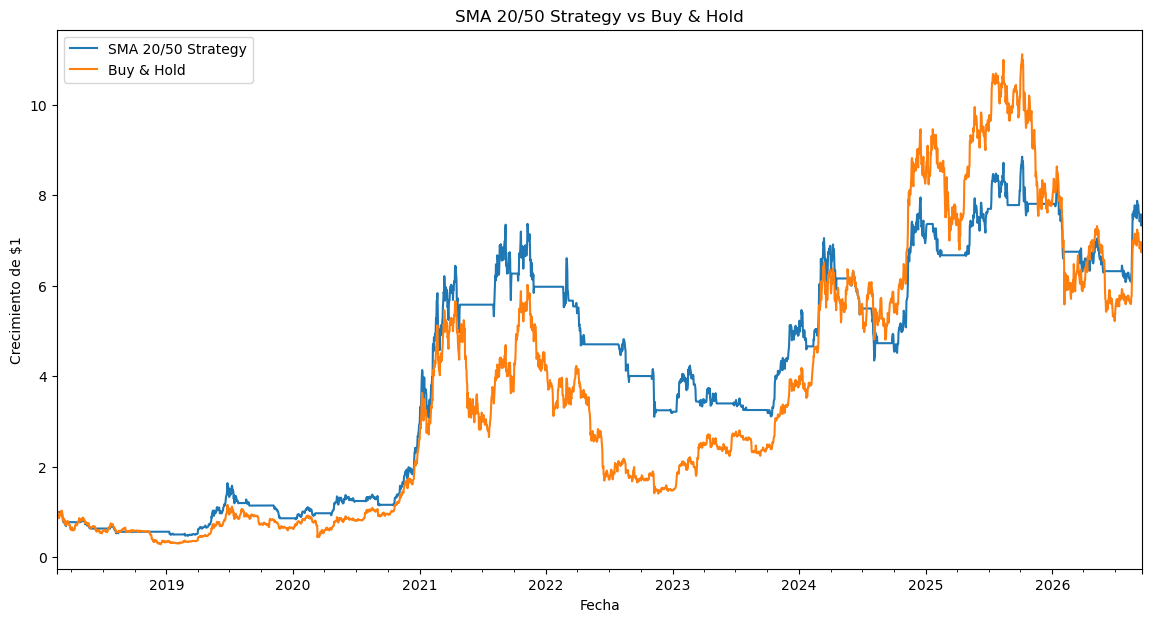

In [43]:
btc[
    ["strategy_cumulative", "buy_hold_cumulative"]
].plot(
    figsize=(14, 7),
    title="SMA 20/50 Strategy vs Buy & Hold"
)

plt.xlabel("Fecha")
plt.ylabel("Crecimiento de $1")
plt.legend(["SMA 20/50 Strategy", "Buy & Hold"])
plt.show()

La línea azul (SMA 20/50) tiene varios tramos prácticamente horizontales. Eso ocurre cuando position = 0: la estrategia está fuera de BTC y, como todavía no estamos modelando intereses sobre el efectivo, su capital permanece constante. Por ejemplo, se ve claramente durante partes de 2021–2023. La línea naranja (Buy & Hold), en cambio, sigue expuesta continuamente y por eso participa tanto de las subidas como de las caídas.
También se aprecia por qué el resultado acumulado de SMA termina ligeramente por encima de Buy & Hold. La estrategia renuncia a algunas subidas —muy evidente en 2025, cuando Buy & Hold supera 10 mientras SMA queda por debajo de 9— pero también evita partes importantes de algunas caídas. Aun así, la gráfica muestra que SMA también tiene retrocesos relevantes: el filtro de medias móviles reduce exposición, pero no elimina el riesgo.

## 9. Análisis de riesgo

La rentabilidad acumulada permite comparar el crecimiento del capital, pero
no es suficiente para evaluar completamente una estrategia de inversión.

Dos estrategias pueden alcanzar resultados similares mediante trayectorias
de riesgo muy diferentes.

Por este motivo, se analizarán las siguientes métricas:

- Volatilidad anualizada
- Sharpe Ratio
- Maximum Drawdown

Estas métricas permitirán evaluar la relación entre rentabilidad y riesgo
de la estrategia SMA 20/50 y compararla con Buy & Hold.

### 9.1 Volatilidad anualizada

La volatilidad mide la dispersión de los retornos y permite cuantificar
cuánto varían los resultados de una estrategia a lo largo del tiempo.

Primero se calcula la desviación estándar de los retornos diarios y luego
se anualiza para facilitar su interpretación.

Dado que Bitcoin opera todos los días del año, se utilizarán 365 períodos
para anualizar la volatilidad diaria.

Ya vimos la volatilidad diaria mediante std():

BTC / Buy & Hold ≈ 3.23%
SMA Strategy     ≈ 2.25%

<p style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'>Ahora queremos pasarla a anual.
La fórmula es:
\[
\sigma_{anual}=\sigma_{diaria}\sqrt{365}
\]La raíz cuadrada es importante: no multiplicamos la volatilidad diaria simplemente por 365.</p>

In [49]:
TRADING_DAYS = 365

strategy_volatility = (
    btc["strategy_return"].std() * np.sqrt(TRADING_DAYS)
)

buy_hold_volatility = (
    btc["buy_hold_return"].std() * np.sqrt(TRADING_DAYS)
)

print(f"Volatilidad anualizada - Strategy: {strategy_volatility:.2%}")
print(f"Volatilidad anualizada - Buy & Hold: {buy_hold_volatility:.2%}")

Volatilidad anualizada - Strategy: 43.04%
Volatilidad anualizada - Buy & Hold: 61.68%


<p style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'>
¿Por qué sqrt(365)?
Este punto vale la pena entenderlo.
Bajo los supuestos habituales de agregación de varianza, la varianza escala aproximadamente con el tiempo:
\[
Var_{anual}\approx365\times Var_{diaria}
\]Pero la volatilidad es la desviación estándar:
\[
\sigma=\sqrt{Var}
\]Por eso:
\[
\sigma_{anual}
=
\sqrt{365\times Var_{diaria}}
=
\sqrt{365}\times\sigma_{diaria}
\]Como:
\[
\sqrt{365}\approx19.1
\]
</p>

<p style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'>La estrategia presenta aproximadamente 18.64 puntos porcentuales menos de volatilidad anualizada. Otra forma de verlo es que su volatilidad es aproximadamente un 30% menor que la de Buy & Hold.</br>
Hasta ahora tenemos dos resultados relevantes: la estrategia terminó con mayor retorno acumulado en este backtest (642.88% vs 582.99%) y, simultáneamente, mostró menor volatilidad anualizada (43.04% vs 61.68%). Esto todavía no basta para evaluar la estrategia: seguimos trabajando con un backtest sin costos y sin validación fuera de muestra.</br>
Ahora podemos avanzar justamente hacia una métrica que relaciona retorno y volatilidad.</p>

### 9.2 Sharpe Ratio

El Sharpe Ratio permite evaluar el retorno obtenido por una estrategia en
relación con el nivel de volatilidad asumido.

Conceptualmente, compara el exceso de retorno de una inversión respecto de
una tasa libre de riesgo con la volatilidad de sus retornos.

En esta primera versión del backtesting se asumirá una tasa libre de riesgo
igual a cero para simplificar el análisis y concentrarnos en la comparación
entre la estrategia SMA 20/50 y Buy & Hold.

<p style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'>
    La fórmula simplificada que vamos a utilizar es:
\[
Sharpe =
\frac{\bar{R}_{diario}}
{\sigma_{diaria}}
\times\sqrt{365}
\]Como inicialmente suponemos:
\[
R_f=0
\]podemos calcularlo así:
</p>

In [54]:
strategy_sharpe = (
    btc["strategy_return"].mean()
    / btc["strategy_return"].std()
) * np.sqrt(TRADING_DAYS)

buy_hold_sharpe = (
    btc["buy_hold_return"].mean()
    / btc["buy_hold_return"].std()
) * np.sqrt(TRADING_DAYS)

print(f"Sharpe Ratio - Strategy: {strategy_sharpe:.2f}")
print(f"Sharpe Ratio - Buy & Hold: {buy_hold_sharpe:.2f}")

Sharpe Ratio - Strategy: 0.76
Sharpe Ratio - Buy & Hold: 0.67


<div style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'><p>La estrategia obtuvo más retorno promedio por unidad de volatilidad que Buy & Hold durante este período, bajo nuestra simplificación de risk-free rate = 0.</p>
<P>Es importante interpretar correctamente el 0.76: no significa 76% de rentabilidad. El Sharpe es un ratio sin unidad. Tampoco concluiría todavía que 0.76 es "bueno" o "malo"; para nuestro experimento lo importante ahora es la comparación consistente entre ambas alternativas.</p>
<p>Hasta este punto:<p/>
</div>

| Métrica | SMA 20/50 | Buy & Hold |
|---|---:|---:|
| Retorno acumulado | 642.88% | 582.99% |
| Volatilidad anualizada | 43.04% | 61.68% |
| Sharpe Ratio | 0.76 | 0.67 |

<p style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'>Ahora necesitamos estudiar algo que el Sharpe no nos cuenta bien: qué tan grande fue la peor caída del capital desde un máximo anterior.</p>

### 9.3 Maximum Drawdown

El Maximum Drawdown mide la mayor caída porcentual experimentada por una
estrategia desde un máximo histórico de capital hasta un mínimo posterior.

Esta métrica permite evaluar la magnitud de la peor pérdida relativa sufrida
durante el período analizado.

Para calcular el drawdown se compara en cada momento el valor acumulado de
la estrategia con el máximo alcanzado hasta ese momento.

<p>Desde 2.00 hasta 1.40:
\[
Drawdown = \frac{1.40}{2.00}-1=-0.30
\]Por lo tanto:
Drawdown = -30%</p>

In [60]:
# Calcular el máximo acumulado:
btc["strategy_peak"] = btc["strategy_cumulative"].cummax()
btc["buy_hold_peak"] = btc["buy_hold_cumulative"].cummax()

In [61]:
# Calculamos drawdown

btc["strategy_drawdown"] = (
    btc["strategy_cumulative"] / btc["strategy_peak"]
) - 1

btc["buy_hold_drawdown"] = (
    btc["buy_hold_cumulative"] / btc["buy_hold_peak"]
) - 1

<p>Cuando estamos exactamente en un máximo:
\[
\frac{2}{2}-1=0
\]No existe drawdown.
Si estamos en 1.40 cuando anteriormente alcanzamos 2.00:
\[
\frac{1.40}{2.00}-1=-0.30
\]Estamos 30% por debajo del máximo anterior.
Finalmente:</p>

In [63]:
strategy_max_drawdown = btc["strategy_drawdown"].min()
buy_hold_max_drawdown = btc["buy_hold_drawdown"].min()

print(f"Maximum Drawdown - Strategy: {strategy_max_drawdown:.2%}")
print(f"Maximum Drawdown - Buy & Hold: {buy_hold_max_drawdown:.2%}")

Maximum Drawdown - Strategy: -57.88%
Maximum Drawdown - Buy & Hold: -76.63%


<div style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'><p>Un -57.88% significa que, en el peor episodio del período, el capital de la estrategia llegó a estar 57.88% por debajo de su máximo histórico anterior. No significa que haya perdido 57.88% durante todo el backtest.</p>
<p>Buy & Hold llegó a estar 76.63% por debajo de uno de sus máximos previos. La diferencia entre ambos drawdowns es de 18.75 puntos porcentuales.</p>
<p>Aun así, hay algo que no debemos perder de vista: -57.88% sigue siendo un drawdown enorme. La SMA reduce considerablemente algunas caídas respecto de mantener BTC permanentemente, pero está lejos de convertir la estrategia en una estrategia de bajo riesgo.
Hasta ahora nuestro resumen es:</p></div>

| Métrica | SMA 20/50 | Buy & Hold |
|---|---:|---:|
| Retorno acumulado | +642.88% | +582.99% |
| Volatilidad anualizada | 43.04% | 61.68% |
| Sharpe Ratio | 0.76 | 0.67 |
| Maximum Drawdown | -57.88% | -76.63% |

### 9.4 Evolución del Drawdown

Además del Maximum Drawdown, es útil observar cómo evolucionaron las caídas
respecto de los máximos históricos a lo largo del tiempo.

Esta visualización permite identificar la profundidad y duración de los
períodos en los que el capital permaneció por debajo de un máximo anterior.

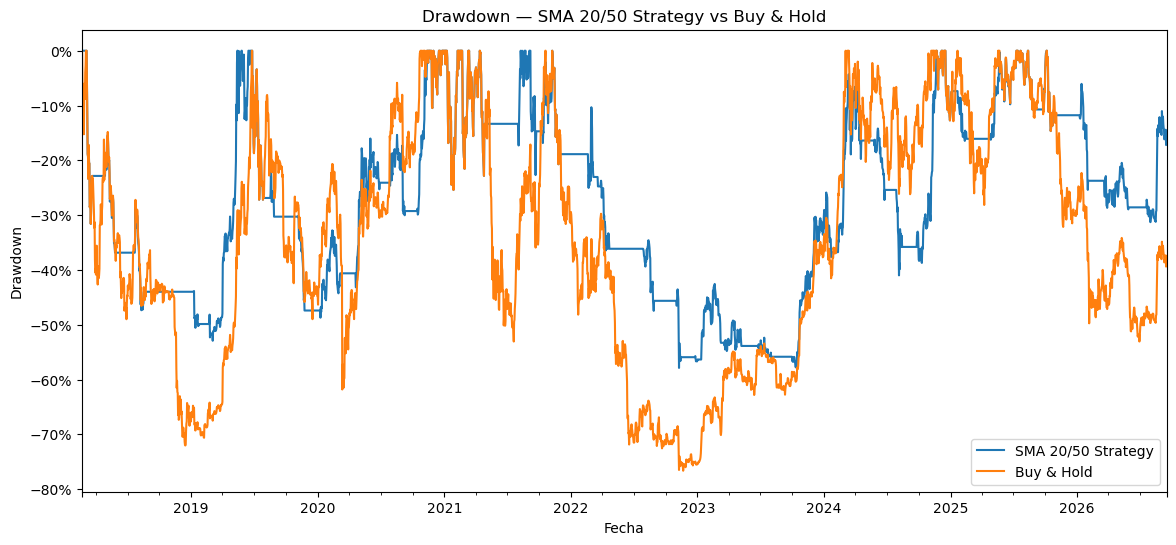

In [67]:
import matplotlib.ticker as mtick

ax = btc[
    ["strategy_drawdown", "buy_hold_drawdown"]
].plot(
    figsize=(14, 6),
    title="Drawdown — SMA 20/50 Strategy vs Buy & Hold"
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend(["SMA 20/50 Strategy", "Buy & Hold"])
plt.show()

<p>¿Qué deberíamos observar?
La gráfica siempre estará en:
\[
Drawdown \leq 0
\]Cuando toca 0%, significa:
el capital está en un nuevo máximo histórico.

Cuando baja, por ejemplo, hasta -40%:
el capital está 40% por debajo de su máximo anterior.

Y hay dos dimensiones que nos interesan: profundidad de la caída y duración del período bajo el máximo. Esta segunda todavía no la estamos cuantificando, pero visualmente empezaremos a verla.</p>

## 10. Operaciones y costos de transacción

Hasta este punto, el backtesting supone que las operaciones pueden ejecutarse
sin ningún costo.

En un mercado real, comprar o vender un activo puede generar costos como
comisiones, spread y slippage.

Antes de incorporar estos costos, se analizarán los cambios de posición
generados por la estrategia SMA 20/50 para determinar cuántas operaciones
se realizaron durante el período estudiado.

### 10.1 Identificación de operaciones

Una operación ocurre cuando la estrategia cambia su posición respecto del
período anterior.

Un cambio de `0` a `1` representa una entrada al mercado, mientras que un
cambio de `1` a `0` representa una salida.

La diferencia entre posiciones consecutivas permite identificar estos
cambios.

In [71]:
btc["trade"] = btc["position"].diff()

btc[
    ["Close", "signal", "position", "trade"]
].head(20)

,Close,signal,position,trade
Date,,,,
2018-02-19,11225.299805,0,NaN,NaN
2018-02-20,11403.700195,0,0.0,NaN
2018-02-21,10690.400391,0,0.0,0.0
2018-02-22,10005.000000,0,0.0,0.0
2018-02-23,10301.099609,0,0.0,0.0
2018-02-24,9813.070312,0,0.0,0.0
2018-02-25,9664.730469,0,0.0,0.0
2018-02-26,10366.700195,0,0.0,0.0
2018-02-27,10725.599609,0,0.0,0.0


### 10.2 Contar operaciones

In [73]:
# Contamos entradas y salidas por separado.
entries = (btc["trade"] == 1).sum()
exits = (btc["trade"] == -1).sum()

total_transactions = (btc["trade"].abs() == 1).sum()

print(f"Entradas: {entries}")
print(f"Salidas: {exits}")
print(f"Transacciones totales: {total_transactions}")


Entradas: 36
Salidas: 35
Transacciones totales: 71


### 10.3 Costos de transacción

Para obtener una estimación más realista del rendimiento de la estrategia,
se incorpora un costo hipotético del **0,10% por transacción**.

Este costo representa de forma simplificada los gastos asociados a la
ejecución de operaciones.

El costo se aplicará cada vez que exista un cambio de posición, tanto al
entrar como al salir del mercado.

In [75]:
TRANSACTION_COST = 0.001

btc["transaction_cost"] = (
    btc["trade"].abs().fillna(0) * TRANSACTION_COST
)

### 10.4 Retorno neto de la estrategia

In [77]:
btc["strategy_return_net"] = (
    btc["strategy_return"] - btc["transaction_cost"]
)

In [78]:
btc.loc[
    btc["trade"].abs() == 1,
    [
        "Close",
        "position",
        "trade",
        "strategy_return",
        "transaction_cost",
        "strategy_return_net"
    ]
].head(10)

,Close,position,trade,strategy_return,transaction_cost,strategy_return_net
Date,,,,,,
2018-03-05,11573.299805,1.0,1.0,0.005273,0.001,0.004273
2018-03-22,8728.469727,0.0,-1.0,-0.000000,0.001,-0.001000
2018-04-28,9348.480469,1.0,1.0,0.040217,0.001,0.039217
2018-05-27,7368.220215,0.0,-1.0,0.000000,0.001,-0.001000
2018-07-23,7711.109863,1.0,1.0,0.039445,0.001,0.038445
2018-08-18,6423.759766,0.0,-1.0,-0.000000,0.001,-0.001000
2019-01-08,4030.847900,1.0,1.0,0.001391,0.001,0.000391
2019-01-27,3583.965820,0.0,-1.0,-0.000000,0.001,-0.001000
2019-02-23,4142.526855,1.0,1.0,0.034203,0.001,0.033203


### 10.5 Rendimiento después de costos

Una vez incorporados los costos de transacción, se recalcula el crecimiento
acumulado de la estrategia utilizando los retornos netos.

Esto permite comparar el resultado del backtesting ideal, sin costos, con
una versión más realista que penaliza cada entrada y salida del mercado.

El objetivo es determinar cuánto impacto tienen los costos de ejecución
sobre el rendimiento acumulado de la estrategia.

In [80]:
# Calculamos nuevamente el crecimiento acumulado

btc["strategy_cumulative_net"] = (
    1 + btc["strategy_return_net"].fillna(0)
).cumprod()

In [81]:
# Obtenemos los tres resultados finales

strategy_final_gross = btc["strategy_cumulative"].iloc[-1]
strategy_final_net = btc["strategy_cumulative_net"].iloc[-1]
buy_hold_final = btc["buy_hold_cumulative"].iloc[-1]

print(f"Strategy sin costos: {strategy_final_gross:.2f}x")
print(f"Strategy con costos: {strategy_final_net:.2f}x")
print(f"Buy & Hold: {buy_hold_final:.2f}x")

Strategy sin costos: 7.43x
Strategy con costos: 6.92x
Buy & Hold: 6.83x


<p style='border: 2px solid #1C6EA4;
border-radius: 14px; padding: 15px'>Una aclaración importante sobre los costos
No debemos calcular:
\[
71\times0.1\%=7.1\%
\]y simplemente restar 7.1% al retorno acumulado de 642.88%.
¿Por qué? Porque las 71 comisiones ocurren en diferentes momentos del tiempo y afectan al capital que posteriormente sigue componiéndose.</p>

### 10.6 Impacto de los costos de transacción

Se comparan las curvas de crecimiento de la estrategia antes y después de
incorporar los costos de transacción, junto con el benchmark Buy & Hold.

Esta comparación permite observar visualmente cuánto se reduce el crecimiento
acumulado de la estrategia cuando se penaliza cada entrada y salida del mercado.


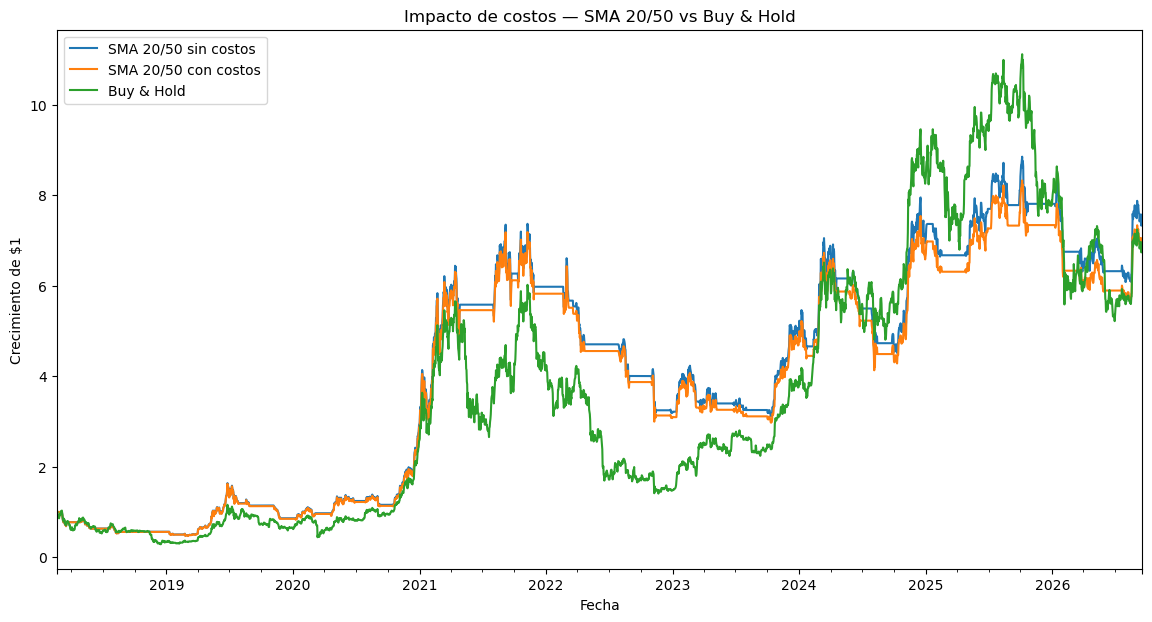

In [84]:
btc[
    [
        "strategy_cumulative",
        "strategy_cumulative_net",
        "buy_hold_cumulative"
    ]
].plot(
    figsize=(14, 7),
    title="Impacto de costos — SMA 20/50 vs Buy & Hold"
)

plt.xlabel("Fecha")
plt.ylabel("Crecimiento de $1")

plt.legend([
    "SMA 20/50 sin costos",
    "SMA 20/50 con costos",
    "Buy & Hold"
])

plt.show()

Los costos reducen considerablemente la diferencia de rentabilidad acumulada
observada entre la estrategia SMA 20/50 y Buy & Hold.

La curva neta permite evaluar una versión más realista del backtesting bajo el
supuesto de un costo fijo del 0,10% por transacción. Esta comparación todavía
no incorpora slippage, impuestos ni rendimiento del efectivo cuando la
estrategia permanece fuera del mercado.


| Resultado final | Capital |
|---|---:|
| SMA 20/50 sin costos | **7.43x** |
| SMA 20/50 con costos | **6.92x** |
| Buy & Hold | **6.83x** |

La estrategia pasa aproximadamente de 7,43x a 6,92x de capital final al
incorporar los costos de transacción. Buy & Hold finaliza aproximadamente en
6,83x.

Es importante no interpretar estos múltiplos directamente como retornos
porcentuales: el capital final incluye la unidad de capital inicial.


Los retornos acumulados deben calcularse restando el capital inicial al múltiplo
final. Por este motivo se utilizan las variables calculadas por Python en la
siguiente celda, en lugar de formatear directamente el capital final como
porcentaje.


In [89]:
strategy_return_gross = strategy_final_gross - 1
strategy_return_net = strategy_final_net - 1
buy_hold_return_total = buy_hold_final - 1

print(f"Retorno Strategy sin costos: {strategy_return_gross:.2%}")
print(f"Retorno Strategy con costos: {strategy_return_net:.2%}")
print(f"Retorno Buy & Hold: {buy_hold_return_total:.2%}")

Retorno Strategy sin costos: 642.88%
Retorno Strategy con costos: 591.93%
Retorno Buy & Hold: 582.99%


<p>Por ejemplo, si empezáramos hipotéticamente con $100:</p>

<p>100 x 7.43 = 743
 </br>
Terminamos con $743, pero nuestra ganancia fue:
 </br>
743-100=643
 </br>
es decir, aproximadamente +643%.
 </br>
Esta distinción entre valor acumulado del capital y retorno acumulado es fundamental y conviene que quede bien presentada en el notebook.
Con esto corregido, seguimos con 10.5 y recalculamos volatilidad, Sharpe y Maximum Drawdown después de costos usando strategy_return_net.</p>

### 10.7 Métricas de riesgo después de costos

La incorporación de costos de transacción modifica los retornos obtenidos por
la estrategia y, por lo tanto, también puede afectar sus métricas de riesgo y
rendimiento ajustado por riesgo.

A continuación se recalculan la volatilidad anualizada, el Sharpe Ratio y el
Maximum Drawdown utilizando los retornos netos de la estrategia.

Los resultados permiten comparar la estrategia original, la estrategia después
de costos y el benchmark Buy & Hold bajo los supuestos definidos en este
backtesting.


In [93]:
# Volatilidad anualizada
strategy_net_volatility = (
    btc["strategy_return_net"].std()
    * np.sqrt(TRADING_DAYS)
)

# Sharpe Ratio
strategy_net_sharpe = (
    btc["strategy_return_net"].mean()
    / btc["strategy_return_net"].std()
) * np.sqrt(TRADING_DAYS)

# Maximum Drawdown
btc["strategy_net_peak"] = (
    btc["strategy_cumulative_net"].cummax()
)

btc["strategy_net_drawdown"] = (
    btc["strategy_cumulative_net"]
    / btc["strategy_net_peak"]
) - 1

strategy_net_max_drawdown = (
    btc["strategy_net_drawdown"].min()
)

print(f"Volatilidad anualizada - Strategy neta: {strategy_net_volatility:.2%}")
print(f"Sharpe Ratio - Strategy neta: {strategy_net_sharpe:.2f}")
print(f"Maximum Drawdown - Strategy neta: {strategy_net_max_drawdown:.2%}")

Volatilidad anualizada - Strategy neta: 43.04%
Sharpe Ratio - Strategy neta: 0.74
Maximum Drawdown - Strategy neta: -58.61%


### 10.8 Conclusiones del análisis de costos

La incorporación de un costo hipotético del 0,10% por transacción reduce de
forma visible la rentabilidad acumulada de la estrategia SMA 20/50.

Durante el período analizado se identificaron 71 transacciones: 36 entradas y
35 salidas. Después de incorporar estos costos, el retorno acumulado de la
estrategia disminuyó de 642,88% a 591,93%, mientras que Buy & Hold obtuvo
582,99%.

El impacto sobre las métricas de riesgo fue menor. La volatilidad anualizada se
mantuvo aproximadamente en 43,04%, el Sharpe Ratio disminuyó de 0,76 a 0,74 y
el Maximum Drawdown pasó de -57,88% a -58,61%.

Bajo los supuestos utilizados en este backtesting, los costos de transacción
reducen considerablemente la diferencia de rentabilidad entre la estrategia y
Buy & Hold. Al mismo tiempo, la estrategia mantiene un perfil histórico de
riesgo diferente, con menor volatilidad y un Maximum Drawdown menos profundo.

Estos resultados describen únicamente el período histórico analizado y todavía
no constituyen evidencia suficiente de que el comportamiento observado pueda
generalizarse a períodos futuros.


## 11. Conclusiones del backtesting

El backtesting realizado muestra que la estrategia SMA 20/50 presentó un
comportamiento diferente a Buy & Hold durante el período histórico analizado.

Después de incorporar un costo hipotético del 0,10% por transacción, la
estrategia obtuvo un retorno acumulado de 591,93%, frente a 582,99% de
Buy & Hold.

La principal diferencia observada se encuentra en las métricas de riesgo. La
estrategia neta presentó una volatilidad anualizada de 43,04%, un Sharpe Ratio
de 0,74 y un Maximum Drawdown de -58,61%, mientras que Buy & Hold registró
61,68%, 0,67 y -76,63%, respectivamente.

Los resultados corresponden exclusivamente al período histórico analizado y a
los supuestos definidos en este backtesting. No constituyen evidencia
suficiente de que el comportamiento observado pueda mantenerse en datos
futuros.

La siguiente etapa del proyecto realizará una validación temporal de la
estrategia para estudiar su comportamiento fuera de muestra.

### Limitaciones

Este backtesting utiliza una representación simplificada de la ejecución de
operaciones. Entre sus principales limitaciones se encuentran:

- costo fijo hipotético del 0,10% por transacción;
- slippage no modelado explícitamente;
- rendimiento del efectivo igual a cero cuando la estrategia está fuera del mercado;
- ausencia de impuestos;
- ausencia de posiciones short y apalancamiento;
- Buy & Hold no incorpora explícitamente un costo inicial de compra;
- resultados todavía no evaluados fuera de muestra.
